# Demonstração: agente em gridworld com Q-learning

Nesta demonstração, criamos um ambiente simples em grade e treinamos um agente com Q-learning. O objetivo é visualizar como o agente aprende por tentativa e erro.

## 1. Importações e configuração
Aqui carregamos as bibliotecas necessárias e definimos uma semente para reprodutibilidade.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import clear_output
import time

%matplotlib inline

SEED = 42
rng = np.random.default_rng(SEED)

## 2. Definir o ambiente
Vamos criar um grid 6x6 com um estado inicial, um objetivo e múltiplos estados de penalidade.

In [2]:
GRID_SIZE = 6
START = (0, 0)
GOAL = (5, 5)
TRAPS = {
    (0, 3), (0, 4),
    (1, 0), (1, 1), (1, 5),
    (2, 2),
    (3, 1), (3, 4),
    (4, 5),
    (5, 3),
}

ACTIONS = ['U', 'D', 'L', 'R']
ACTION_TO_DELTA = {
    'U': (-1, 0),
    'D': (1, 0),
    'L': (0, -1),
    'R': (0, 1),
}

N_STATES = GRID_SIZE * GRID_SIZE
N_ACTIONS = len(ACTIONS)

def state_to_idx(state):
    return state[0] * GRID_SIZE + state[1]

def idx_to_state(idx):
    return (idx // GRID_SIZE, idx % GRID_SIZE)

def step(state, action):
    if state == GOAL or state in TRAPS:
        return state, 0.0, True

    r, c = state
    dr, dc = ACTION_TO_DELTA[action]
    nr = min(max(r + dr, 0), GRID_SIZE - 1)
    nc = min(max(c + dc, 0), GRID_SIZE - 1)
    next_state = (nr, nc)

    reward = -0.04
    done = False
    if next_state == GOAL:
        reward = 1.0
        done = True
    elif next_state in TRAPS:
        reward = -1.0
        done = True

    return next_state, reward, done

## 3. Visualizar o grid
Representamos o ambiente com S (start), G (goal) e X (traps).

In [3]:
def render_grid():
    grid = [['.' for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]
    grid[START[0]][START[1]] = 'S'
    grid[GOAL[0]][GOAL[1]] = 'G'
    for trap in TRAPS:
        grid[trap[0]][trap[1]] = 'X'
    for row in grid:
        print(' '.join(row))

render_grid()

S . . X X .
X X . . . X
. . X . . .
. X . . X .
. . . . . X
. . . X . G


Abaixo, uma visualização com cores do ambiente, útil para acompanhar o agente.


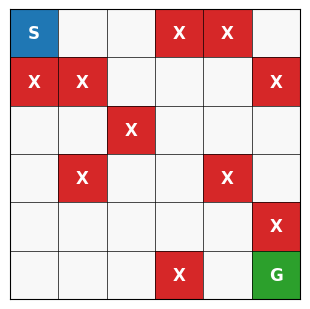

In [4]:
def render_grid_mat(agent=None, path=None):
    grid = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
    grid[START] = 1
    grid[GOAL] = 2
    for trap in TRAPS:
        grid[trap] = 3

    if path:
        for s in path:
            if s not in (START, GOAL) and s not in TRAPS:
                grid[s] = 5

    if agent and agent not in (START, GOAL) and agent not in TRAPS:
        grid[agent] = 4

    cmap = ListedColormap([
        '#f8f8f8',  # vazio
        '#1f77b4',  # start
        '#2ca02c',  # goal
        '#d62728',  # trap
        '#ff7f0e',  # agente
        '#9467bd',  # caminho
    ])

    fig, ax = plt.subplots(figsize=(3.2, 3.2))
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=5)
    ax.set_xticks(range(GRID_SIZE))
    ax.set_yticks(range(GRID_SIZE))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, GRID_SIZE, 1), minor=True)
    ax.grid(which='minor', color='black', linewidth=0.5)
    ax.tick_params(which='both', bottom=False, left=False)

    ax.text(START[1], START[0], 'S', ha='center', va='center', color='white', fontsize=12, weight='bold')
    ax.text(GOAL[1], GOAL[0], 'G', ha='center', va='center', color='white', fontsize=12, weight='bold')
    for trap in TRAPS:
        ax.text(trap[1], trap[0], 'X', ha='center', va='center', color='white', fontsize=12, weight='bold')

    if agent and agent not in (START, GOAL) and agent not in TRAPS:
        ax.text(agent[1], agent[0], 'A', ha='center', va='center', color='black', fontsize=12, weight='bold')

    plt.tight_layout()
    plt.show()

render_grid_mat(agent=START)


## 4. Linha de base aleatória
Antes de treinar, estimamos o retorno médio de uma política aleatória.

In [5]:
def run_episode(policy_fn, max_steps=50):
    state = START
    total_reward = 0.0
    for _ in range(max_steps):
        action = policy_fn(state)
        next_state, reward, done = step(state, action)
        total_reward += reward
        state = next_state
        if done:
            break
    return total_reward

def random_policy(state):
    return rng.choice(ACTIONS)

baseline_returns = [run_episode(random_policy) for _ in range(200)]
print(f'Retorno médio (aleatório): {np.mean(baseline_returns):.3f}')

Retorno médio (aleatório): -1.114


## 5. Treinar com Q-learning
Agora treinamos o agente com exploração epsilon-greedy.

In [6]:
Q = np.zeros((N_STATES, N_ACTIONS))

alpha = 0.1
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

episode_returns = []

for episode in range(500):
    state = START
    total_reward = 0.0

    for _ in range(50):
        s_idx = state_to_idx(state)
        if rng.random() < epsilon:
            a_idx = int(rng.integers(N_ACTIONS))
        else:
            a_idx = int(np.argmax(Q[s_idx]))

        action = ACTIONS[a_idx]
        next_state, reward, done = step(state, action)
        s_next_idx = state_to_idx(next_state)

        td_target = reward + gamma * np.max(Q[s_next_idx])
        Q[s_idx, a_idx] += alpha * (td_target - Q[s_idx, a_idx])

        total_reward += reward
        state = next_state

        if done:
            break

    episode_returns.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

## 6. Curva de aprendizado
Visualizamos o retorno por episódio.

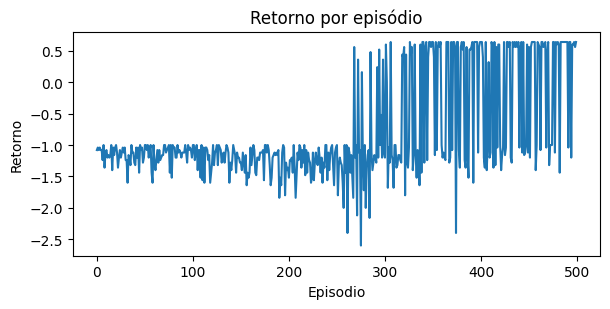

In [7]:
plt.figure(figsize=(6.2, 3.2))
plt.plot(episode_returns)
plt.title('Retorno por episódio')
plt.xlabel('Episodio')
plt.ylabel('Retorno')
plt.tight_layout()
plt.show()

## 7. Política aprendida
Extraimos a melhor ação em cada estado.

In [8]:
def policy_from_Q(Q):
    policy = {}
    for idx in range(N_STATES):
        state = idx_to_state(idx)
        if state == GOAL:
            policy[state] = 'G'
        elif state in TRAPS:
            policy[state] = 'X'
        else:
            best_action = ACTIONS[int(np.argmax(Q[idx]))]
            policy[state] = best_action
    return policy

policy = policy_from_Q(Q)

for r in range(GRID_SIZE):
    row = []
    for c in range(GRID_SIZE):
        row.append(policy[(r, c)])
    print(' '.join(row))

R R D X X U
X X R D D X
D L X D L L
D X R D X R
R R R R D X
L U D X R G


## 8. Teste de um episódio
Rodamos um episódio com a política aprendida.

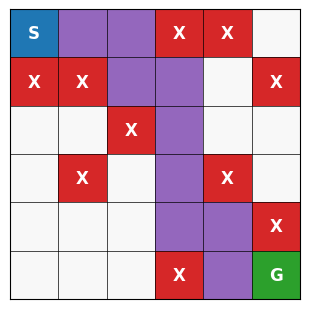

Caminho: [(0, 0), (0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 3), (4, 3), (4, 4), (5, 4), (5, 5)]
Retorno total: 0.640


In [9]:
state = START
path = [state]
total_reward = 0.0

clear_output(wait=True)
render_grid_mat(agent=state, path=path)
time.sleep(0.5)

for _ in range(30):
    action = policy.get(state, 'G')
    if action in ('G', 'X'):
        break
    next_state, reward, done = step(state, action)
    total_reward += reward
    state = next_state
    path.append(state)

    clear_output(wait=True)
    render_grid_mat(agent=state, path=path)
    time.sleep(0.3)

    if done:
        break

print('Caminho:', path)
print(f'Retorno total: {total_reward:.3f}')


## 9. Observações finais
Mesmo em um ambiente simples, o agente aprende a preferir trajetórias mais curtas e evitar estados de penalidade.